In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem.isri import ISRIStemmer

nltk.download('stopwords')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
# Load files
neg_train = pd.read_csv("train_Arabic_tweets_negative_20190413.tsv", sep='\t', header=None)
pos_train = pd.read_csv("train_Arabic_tweets_positive_20190413.tsv", sep='\t', header=None)

# Add labels
neg_train['label'] = 0
pos_train['label'] = 1

# Drop the first column (which contains 'neg' or 'pos' string) and rename the second column (which contains the text)
neg_train = neg_train.drop(columns=[0]).rename(columns={1: 'text'})
pos_train = pos_train.drop(columns=[0]).rename(columns={1: 'text'})

# Merge
df = pd.concat([neg_train, pos_train], axis=0).reset_index(drop=True)


In [4]:
df.head()

,text,label
0,اعترف ان بتس كانو شوي شوي يجيبو راسي لكن اليوم...,0
1,توقعت اذا جات داريا بشوفهم كاملين بس لي للحين ...,0
2,#الاهلي_الهلال اكتب توقعك لنتيجة لقاء الهلال و...,0
3,نعمة المضادات الحيوية . تضع قطرة💧مضاد بنسلين ع...,0
4,الدودو جايه تكمل علي 💔,0


In [5]:
arabic_stopwords = set(stopwords.words('arabic'))
stemmer = ISRIStemmer()

def preprocess_arabic(text):

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove mentions & hashtags
    text = re.sub(r"@\w+|#\w+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = re.sub(f"[{string.punctuation}]", "", text)

    # Normalize Arabic letters
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)

    # Remove Tashkeel
    text = re.sub(r"[ًٌٍَُِّْ]", "", text)

    # Remove Tatweel
    text = re.sub(r"ـ", "", text)

    # Tokenization
    words = text.split()

    # Remove stopwords + stemming
    words = [stemmer.stem(w) for w in words if w not in arabic_stopwords]

    return " ".join(words)

In [6]:
# Apply Preprocessing
df['clean_text'] = df['text'].apply(preprocess_arabic)

In [7]:
df.head()

,text,label,clean_text
0,اعترف ان بتس كانو شوي شوي يجيبو راسي لكن اليوم...,0,عرف ان بتس كنو شوي شوي جيبو رسي اليوم زيد 😭
1,توقعت اذا جات داريا بشوفهم كاملين بس لي للحين ...,0,وقع اذا جات دار بشف كمل حين احس احد نقص 💔
2,#الاهلي_الهلال اكتب توقعك لنتيجة لقاء الهلال و...,0,كتب وقع نتج لقء هلل اهل تاق 👇 دخل سحب قيم ايف ...
3,نعمة المضادات الحيوية . تضع قطرة💧مضاد بنسلين ع...,0,نعم ضاد حيي تضع قطره💧مضاد نسل علي كتر 🦠 فجر 💥 ...
4,الدودو جايه تكمل علي 💔,0,دودو جيه كمل علي 💔


In [8]:
# TF-IDF + N-Grams
vectorizer = TfidfVectorizer(
  ngram_range=(1,2),
  max_features=100000,
  sublinear_tf=True,
  min_df=5,
  max_df=0.9,
  use_idf=True,
  smooth_idf=True,
  norm='l2',
  encoding='utf-8',
  decode_error='ignore',
  analyzer='word',
  stop_words=None
)

x=vectorizer.fit_transform(df['clean_text'])
y=df['label']

In [9]:
# Train/Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)


In [10]:
# Models -- Naive Bayes
nb_model=MultinomialNB()
nb_model.fit(x_train, y_train)

y_pred_nb=nb_model.predict(x_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7510767531750414
              precision    recall  f1-score   support

           0       0.73      0.79      0.76      4503
           1       0.77      0.71      0.74      4552

    accuracy                           0.75      9055
   macro avg       0.75      0.75      0.75      9055
weighted avg       0.75      0.75      0.75      9055



In [11]:
#  Logistic Regression
param_grid={
    'C':[0.1,1,10]
}

lr= LogisticRegression(max_iter=1000)
grid=GridSearchCV(lr,param_grid,cv=3,n_jobs=-1)
grid.fit(x_train,y_train)

best_lr = grid.best_estimator_

y_pred_lr = best_lr.predict(x_test)

print("Best Params:", grid.best_params_)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Best Params: {'C': 10}
Logistic Regression Accuracy: 0.7634456101601326


In [12]:
# Evaluation --- Classification Report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.76      0.77      0.76      4503
           1       0.77      0.75      0.76      4552

    accuracy                           0.76      9055
   macro avg       0.76      0.76      0.76      9055
weighted avg       0.76      0.76      0.76      9055



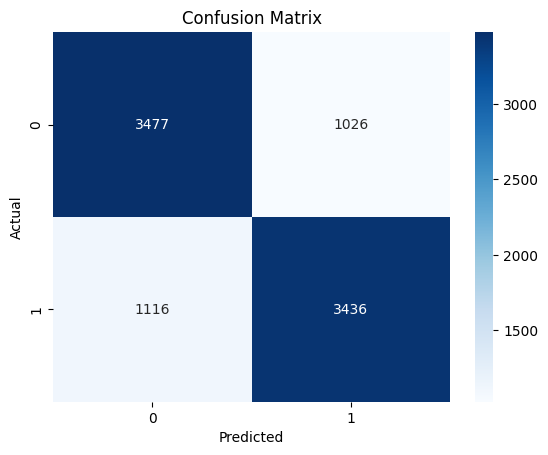

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
# Comparison
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Naive Bayes Accuracy: 0.7510767531750414
Logistic Regression Accuracy: 0.7634456101601326


# RNN Implementation

### Data Preparation for RNN


In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Parameters for tokenization and padding
VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 100

# Initialize tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<unk>')
tokenizer.fit_on_texts(df['clean_text'])

# Convert text to sequences of integers
X_rnn = tokenizer.texts_to_sequences(df['clean_text'])

# Pad sequences to a fixed length
X_rnn = pad_sequences(X_rnn, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

y_rnn = df['label'].values

print(f"Shape of tokenized and padded data: {X_rnn.shape}")
print(f"Shape of labels: {y_rnn.shape}")

Shape of tokenized and padded data: (45275, 100)
Shape of labels: (45275,)


In [16]:
# Split the data into training and testing sets for RNN
X_train_rnn, X_test_rnn, y_train_rnn, y_test_rnn = train_test_split(
    X_rnn, y_rnn, test_size=0.2, random_state=42, stratify=y_rnn
)

print(f"X_train_rnn shape: {X_train_rnn.shape}")
print(f"X_test_rnn shape: {X_test_rnn.shape}")
print(f"y_train_rnn shape: {y_train_rnn.shape}")
print(f"y_test_rnn shape: {y_test_rnn.shape}")

X_train_rnn shape: (36220, 100)
X_test_rnn shape: (9055, 100)
y_train_rnn shape: (36220,)
y_test_rnn shape: (9055,)


### Building the RNN Model



In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, BatchNormalization

# Parameters for the Embedding layer
EMBEDDING_DIM = 128

# Build the RNN model with multiple SimpleRNN layers and BatchNormalization
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    SimpleRNN(128, return_sequences=True), # First SimpleRNN layer
    BatchNormalization(),
    Dropout(0.5),
    SimpleRNN(128, return_sequences=False), # Second SimpleRNN layer
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'), # Hidden dense layer
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Training the RNN Model



In [18]:
BATCH_SIZE = 64
EPOCHS = 10

history = model.fit(
    X_train_rnn,
    y_train_rnn,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

print("Model training complete!")

Epoch 1/10
510/510 ━━━━━━━━━━━━━━━━━━━━ 80s 147ms/step - accuracy: 0.4948 - loss: 0.7981 - val_accuracy: 0.5058 - val_loss: 0.6930
Epoch 2/10
510/510 ━━━━━━━━━━━━━━━━━━━━ 77s 151ms/step - accuracy: 0.5070 - loss: 0.7012 - val_accuracy: 0.5064 - val_loss: 0.6927
Epoch 3/10
510/510 ━━━━━━━━━━━━━━━━━━━━ 79s 145ms/step - accuracy: 0.4999 - loss: 0.6957 - val_accuracy: 0.5052 - val_loss: 0.6931
Epoch 4/10
510/510 ━━━━━━━━━━━━━━━━━━━━ 85s 150ms/step - accuracy: 0.5002 - loss: 0.6940 - val_accuracy: 0.4953 - val_loss: 0.6933
Epoch 5/10
510/510 ━━━━━━━━━━━━━━━━━━━━ 75s 146ms/step - accuracy: 0.5026 - loss: 0.6938 - val_accuracy: 0.5058 - val_loss: 0.6931
Epoch 6/10
510/510 ━━━━━━━━━━━━━━━━━━━━ 75s 146ms/step - accuracy: 0.5039 - loss: 0.6936 - val_accuracy: 0.5058 - val_loss: 0.6931
Epoch 7/10
510/510 ━━━━━━━━━━━━━━━━━━━━ 85s 153ms/step - accuracy: 0.5018 - loss: 0.6935 - val_accuracy: 0.5058 - val_loss: 0.6932
Epoch 8/10
510/510 ━━━━━━━━━━━━━━━━━━━━ 75s 147ms/step - accuracy: 0.5012 - loss: 0

### Evaluating the RNN Model



In [19]:
# Predict probabilities on the test set
y_pred_proba_rnn = model.predict(X_test_rnn)

y_pred_rnn = (y_pred_proba_rnn > 0.5).astype(int)


rnn_accuracy = accuracy_score(y_test_rnn, y_pred_rnn)
print(f"RNN Model Accuracy: {rnn_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_rnn, y_pred_rnn))

283/283 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step
RNN Model Accuracy: 0.5101

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.93      0.65      4503
           1       0.58      0.09      0.16      4552

    accuracy                           0.51      9055
   macro avg       0.54      0.51      0.41      9055
weighted avg       0.54      0.51      0.41      9055



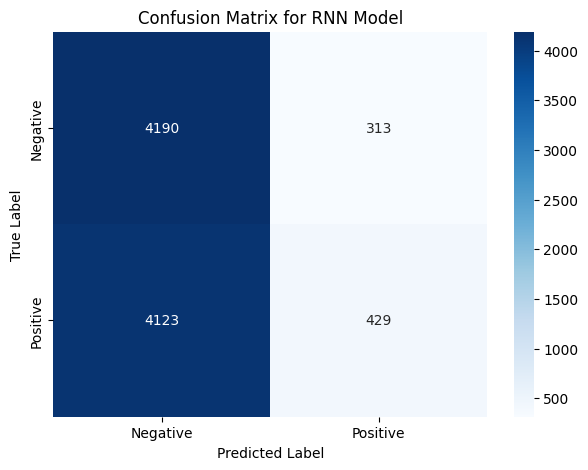

In [20]:
# Confusion Matrix for RNN
cm_rnn = confusion_matrix(y_test_rnn, y_pred_rnn)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for RNN Model")
plt.show()

### Visualizing Training History


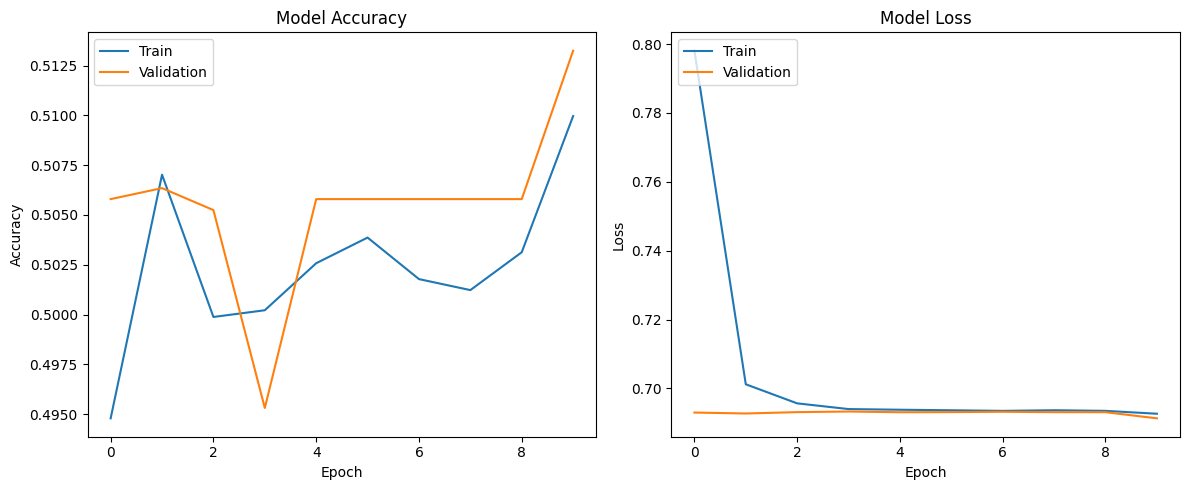

In [21]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

### Comparison with Previous Models


In [22]:
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"RNN Model Accuracy: {rnn_accuracy:.4f}")

Naive Bayes Accuracy: 0.7511
Logistic Regression Accuracy: 0.7634
RNN Model Accuracy: 0.5101
